# Dataset-Level Attribution Analysis (U-ED-LSTM Sepsis)

This notebook computes and analyzes attribution patterns across the full dataset:

1. **Average feature attribution** for Activity, Resource, and temporal features
2. **Attribution by categorical value** for top-5 most common activities and resources
3. **Test mode** for quick validation with a subset

**Note**: Full dataset computation can take significant time. Use test mode first.

## 1. Setup

In [1]:
# Path setup and config import
import sys
from pathlib import Path

_current = Path().resolve()
while _current != _current.parent:
    if (_current / 'src').is_dir():
        break
    _current = _current.parent

# Add both project root and src/ to path (src/ needed for pickle compatibility)
if str(_current) not in sys.path:
    sys.path.insert(0, str(_current))
if str(_current / 'src') not in sys.path:
    sys.path.insert(0, str(_current / 'src'))

from src.interpretability.config.sepsis_config import CONFIG
print(f"Dataset: {CONFIG.dataset_name}")

Dataset: Sepsis


In [2]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
from collections import defaultdict
import pickle
import random

from src.model.dropout_uncertainty_enc_dec_LSTM.dropout_uncertainty_model import DropoutUncertaintyEncoderDecoderLSTM
from src.evaluation.evaluation import Evaluation
from src.interpretability import InterpretabilityTool

plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

# Reproducibility
SEED = CONFIG.seed
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [3]:
# Load model and data
model = DropoutUncertaintyEncoderDecoderLSTM.load(str(CONFIG.get_model_path()), dropout=0.0)
model.eval()
device = torch.device('cpu')
model = model.to(device)

test_dataset = torch.load(str(CONFIG.get_test_data_path()), weights_only=False)

eval_helper = Evaluation(
    model=model,
    dataset=test_dataset,
    concept_name=CONFIG.concept_name,
    growing_num_values=CONFIG.growing_num_values,
    all_cat=CONFIG.all_cat,
    all_num=CONFIG.all_num
)

tool = InterpretabilityTool(model, model.data_set_categories, device=device)

print(f"Loaded {len(test_dataset)} samples")
print(f"Available cases: {len(eval_helper.cases)}")

Data set categories:  ([('concept:name', 18, {'Admission IC': 1, 'Admission NC': 2, 'CRP': 3, 'EOS': 4, 'ER Registration': 5, 'ER Sepsis Triage': 6, 'ER Triage': 7, 'IV Antibiotics': 8, 'IV Liquid': 9, 'LacticAcid': 10, 'Leucocytes': 11, 'Release A': 12, 'Release B': 13, 'Release C': 14, 'Release D': 15, 'Release E': 16, 'Return ER': 17}), ('InfectionSuspected', 5, {'EOS': 1, 'False': 2, 'True': 3, nan: 4}), ('org:group', 27, {'?': 1, 'A': 2, 'B': 3, 'C': 4, 'D': 5, 'E': 6, 'EOS': 7, 'F': 8, 'G': 9, 'H': 10, 'I': 11, 'J': 12, 'K': 13, 'L': 14, 'M': 15, 'N': 16, 'O': 17, 'P': 18, 'Q': 19, 'R': 20, 'S': 21, 'T': 22, 'U': 23, 'V': 24, 'W': 25, 'X': 26}), ('DiagnosticBlood', 5, {'EOS': 1, 'False': 2, 'True': 3, nan: 4}), ('DisfuncOrg', 5, {'EOS': 1, 'False': 2, 'True': 3, nan: 4}), ('SIRSCritTachypnea', 5, {'EOS': 1, 'False': 2, 'True': 3, nan: 4}), ('Hypotensie', 5, {'EOS': 1, 'False': 2, 'True': 3, nan: 4}), ('SIRSCritHeartRate', 5, {'EOS': 1, 'False': 2, 'True': 3, nan: 4}), ('Infusion'

## 2. Configuration

In [4]:
# ============================================================
# CONFIGURATIONc
# ============================================================
TEST_MODE = False          # Set to False for full dataset analysis
CONFIG.use_improved = False  # set True for the improved variant
TEST_SAMPLE_SIZE = 200     # Number of samples in test mode
IG_STEPS = 30             # Integration steps (reduce for speed)
TARGET = CONFIG.concept_name  # Attribution target

# Get ALL input features from the model (not a subset)
# This ensures attribution is always computed w.r.t. all input features
cat_categories, num_categories = model.data_set_categories
ALL_CAT_FEATURES = [name for name, _, _ in cat_categories]
ALL_NUM_FEATURES = [name for name, _, _ in num_categories]
ALL_FEATURES = ALL_CAT_FEATURES + ALL_NUM_FEATURES

print(f"Mode: {'TEST' if TEST_MODE else 'FULL'}")
print(f"All input features ({len(ALL_FEATURES)} total):")
print(f"  Categorical: {ALL_CAT_FEATURES}")
print(f"  Numerical: {ALL_NUM_FEATURES}")

Mode: FULL
All input features (34 total):
  Categorical: ['concept:name', 'InfectionSuspected', 'org:group', 'DiagnosticBlood', 'DisfuncOrg', 'SIRSCritTachypnea', 'Hypotensie', 'SIRSCritHeartRate', 'Infusion', 'DiagnosticArtAstrup', 'DiagnosticIC', 'DiagnosticSputum', 'DiagnosticLiquor', 'DiagnosticOther', 'SIRSCriteria2OrMore', 'DiagnosticXthorax', 'SIRSCritTemperature', 'DiagnosticUrinaryCulture', 'SIRSCritLeucos', 'Oligurie', 'DiagnosticLacticAcid', 'lifecycle:transition', 'Diagnose', 'Hypoxie', 'DiagnosticUrinarySediment', 'DiagnosticECG']
  Numerical: ['case_elapsed_time', 'event_elapsed_time', 'day_in_week', 'seconds_in_day', 'Age', 'Leucocytes', 'CRP', 'LacticAcid']


## 3. Prepare Samples

In [5]:
# Collect all prefix-suffix pairs
all_samples = []

for case_name, full_case in tqdm(eval_helper.cases.items(), desc="Collecting samples"):
    for prefix_len, prefix, suffix in eval_helper._iterate_case(full_case):
        if prefix_len >= 1:  # At least 1 event
            all_samples.append({
                'case_name': case_name,
                'prefix_len': prefix_len,
                'prefix': prefix,
                'suffix': suffix
            })

print(f"Total samples: {len(all_samples)}")

# Sample if in test mode
if TEST_MODE:
    samples = random.sample(all_samples, min(TEST_SAMPLE_SIZE, len(all_samples)))
    print(f"Using {len(samples)} samples (test mode)")
else:
    samples = all_samples
    print(f"Using all {len(samples)} samples (full mode)")

Total samples: 2589
Using all 2589 samples (full mode)


## 4. Compute Attributions

In [6]:
# Compute attributions for all samples
attribution_results = []

for sample in tqdm(samples, desc="Computing attributions"):
    try:
        prefix = sample['prefix']
        prefix_len = sample['prefix_len']
        
        # Convert prefix
        cat_tensors = [t.squeeze(0) if t.dim() > 1 else t for t in prefix[0]]
        num_tensors = [t.squeeze(0) if t.dim() > 1 else t for t in prefix[1]]
        process = (cat_tensors, num_tensors)
        
        # Compute attribution
        attr_map = tool.compute_attribution_map(
            process=process,
            prefix_length=prefix_len,
            target=TARGET,
            target_class='auto',
            method='integrated_gradients',
            n_steps=IG_STEPS
        )
        
        # Extract feature attributions
        feature_attrs = {}
        for feat in attr_map.feature_names:
            if feat in attr_map.attributions:
                vals = attr_map.attributions[feat]
                if hasattr(vals, 'detach'):
                    vals = vals.detach().cpu().numpy()
                feature_attrs[feat] = np.abs(vals).sum()
        
        # Get predicted activity
        pred_activity = attr_map.target_description.split('=')[1].split('(')[0].strip() if '=' in attr_map.target_description else 'Unknown'
        
        attribution_results.append({
            'case_name': sample['case_name'],
            'prefix_len': prefix_len,
            'predicted_activity': pred_activity,
            **feature_attrs
        })
        
    except Exception as e:
        print(f"Error for {sample['case_name']}: {e}")

results_df = pd.DataFrame(attribution_results)
print(f"\nComputed attributions for {len(results_df)} samples")

Computing attributions:   0%|          | 0/2589 [00:00<?, ?it/s]


Computed attributions for 2589 samples


## 5. Average Feature Attribution (4 Views)

In [7]:
# Compute average attribution per feature
available_features = [f for f in ALL_FEATURES if f in results_df.columns]

avg_attribution = results_df[available_features].mean()
std_attribution = results_df[available_features].std()

print("Average Feature Attribution:")
print("="*60)
for feat in available_features:
    print(f"{feat:25s}: {avg_attribution[feat]:.6f} ± {std_attribution[feat]:.6f}")

Average Feature Attribution:
concept:name             : 0.150935 ± 0.128082
InfectionSuspected       : 0.002651 ± 0.002354
org:group                : 0.222657 ± 0.072169
DiagnosticBlood          : 0.005358 ± 0.005873
DisfuncOrg               : 0.003848 ± 0.004467
SIRSCritTachypnea        : 0.011966 ± 0.012282
Hypotensie               : 0.002415 ± 0.002547
SIRSCritHeartRate        : 0.005039 ± 0.004549
Infusion                 : 0.005734 ± 0.005091
DiagnosticArtAstrup      : 0.008429 ± 0.008548
DiagnosticIC             : 0.004147 ± 0.004644
DiagnosticSputum         : 0.026131 ± 0.026646
DiagnosticLiquor         : 0.010800 ± 0.009045
DiagnosticOther          : 0.007192 ± 0.007280
SIRSCriteria2OrMore      : 0.009672 ± 0.010706
DiagnosticXthorax        : 0.007288 ± 0.006294
SIRSCritTemperature      : 0.019388 ± 0.019322
DiagnosticUrinaryCulture : 0.002458 ± 0.002090
SIRSCritLeucos           : 0.004407 ± 0.005506
Oligurie                 : 0.005519 ± 0.005136
DiagnosticLacticAcid     : 0.00

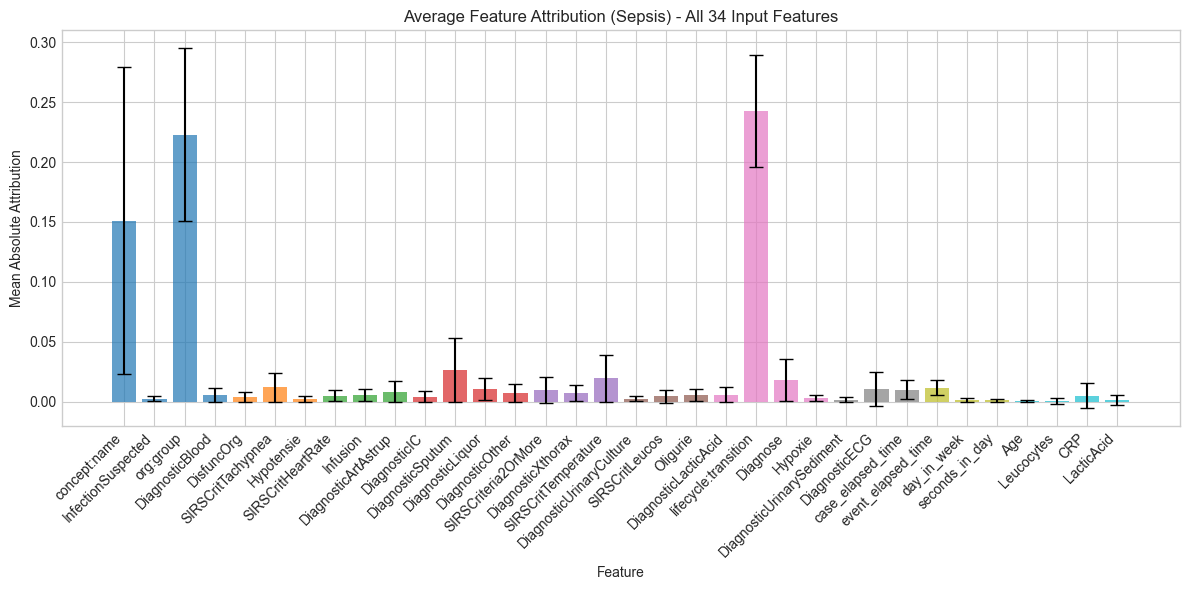

In [8]:
# View 1: Bar chart of average attribution
fig, ax = plt.subplots(figsize=(12, 6))

# Use a colormap that scales with number of features
colors = plt.cm.tab10(np.linspace(0, 1, len(available_features)))
bars = ax.bar(available_features, avg_attribution[available_features], 
              yerr=std_attribution[available_features], capsize=5, 
              color=colors, alpha=0.7)

ax.set_ylabel('Mean Absolute Attribution')
ax.set_xlabel('Feature')
ax.set_title(f'Average Feature Attribution ({CONFIG.dataset_name}) - All {len(available_features)} Input Features')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

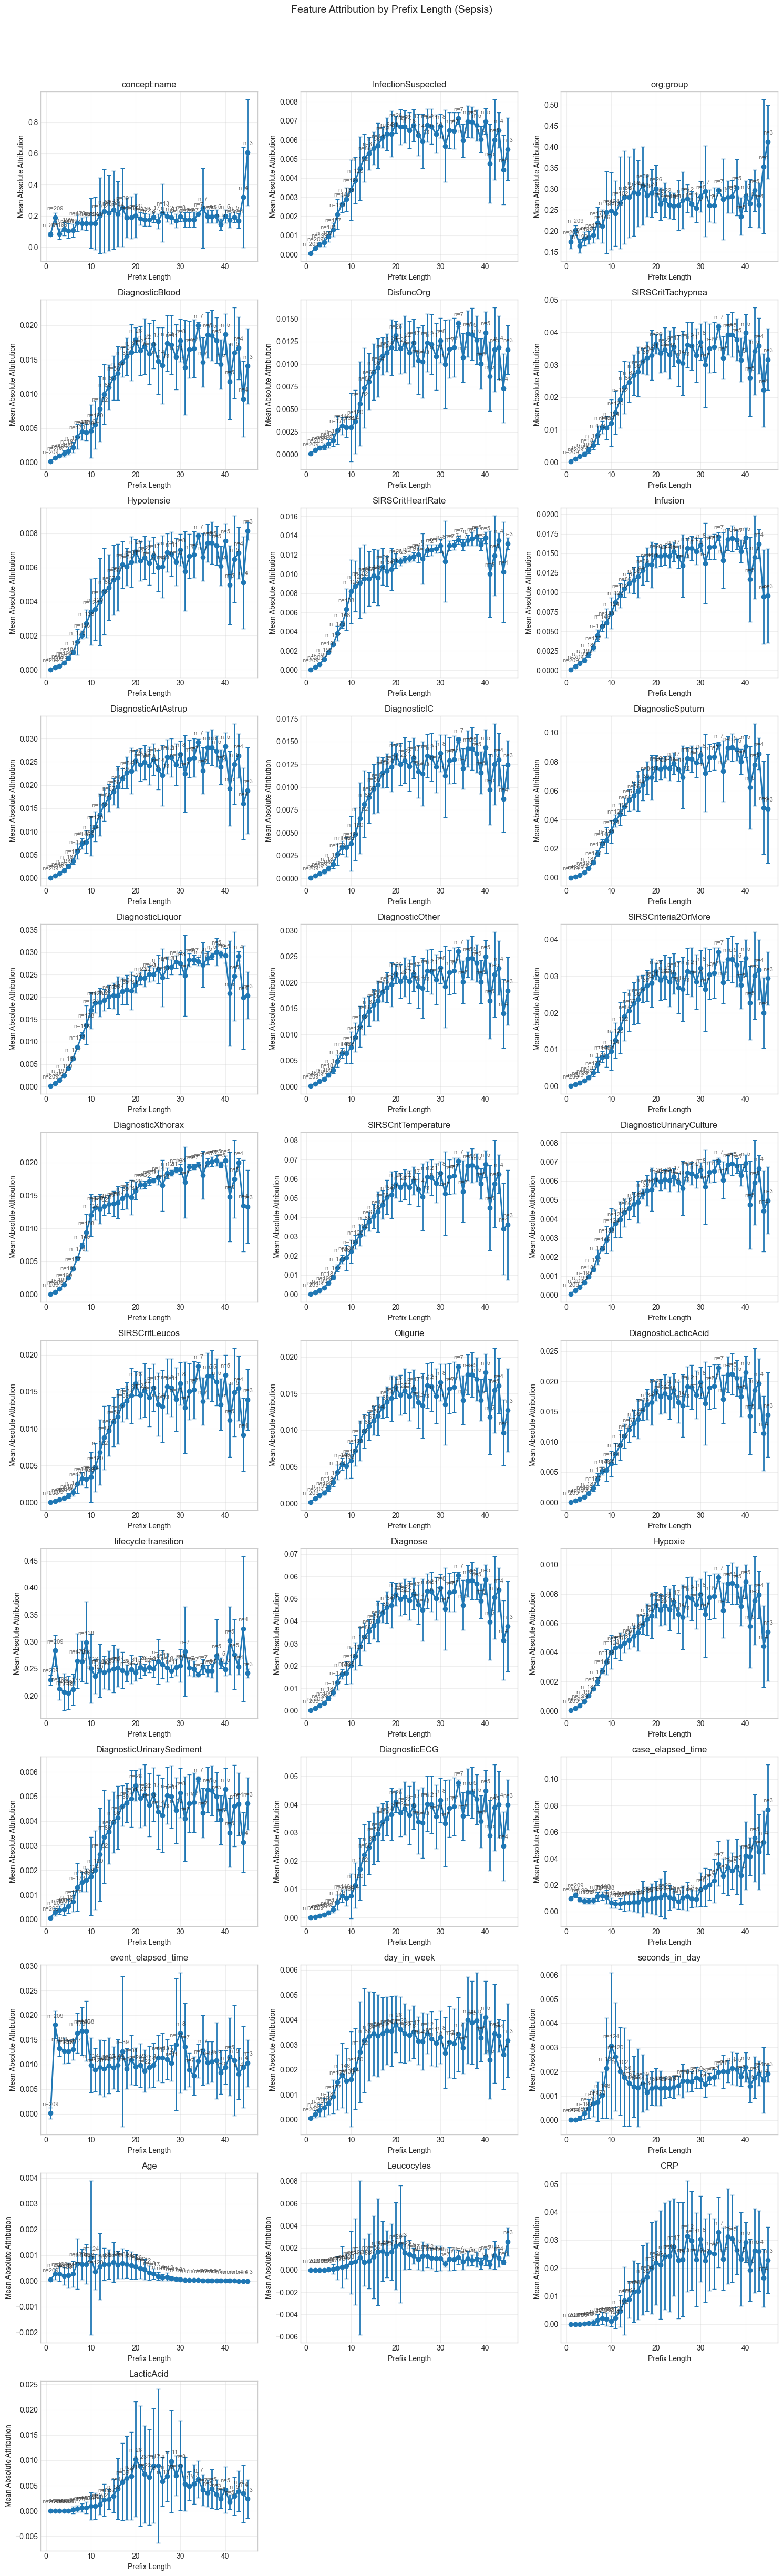


Sample distribution by prefix length:
  Prefix 1: n=209
  Prefix 2: n=209
  Prefix 3: n=199
  Prefix 4: n=199
  Prefix 5: n=181
  Prefix 6: n=177
  Prefix 7: n=173
  Prefix 8: n=146
  Prefix 9: n=138
  Prefix 10: n=124
  Prefix 11: n=120
  Prefix 12: n=102
  Prefix 13: n=86
  Prefix 14: n=67
  Prefix 15: n=56
  Prefix 16: n=44
  Prefix 17: n=39
  Prefix 18: n=34
  Prefix 19: n=31
  Prefix 20: n=26
  Prefix 21: n=23
  Prefix 22: n=22
  Prefix 23: n=18
  Prefix 24: n=17
  Prefix 25: n=14
  Prefix 26: n=13
  Prefix 27: n=12
  Prefix 28: n=11
  Prefix 29: n=10
  Prefix 30: n=8
  Prefix 31: n=7
  Prefix 32: n=7
  Prefix 33: n=7
  Prefix 34: n=7
  Prefix 35: n=7
  Prefix 36: n=5
  Prefix 37: n=5
  Prefix 38: n=5
  Prefix 39: n=5
  Prefix 40: n=5
  Prefix 41: n=5
  Prefix 42: n=5
  Prefix 43: n=4
  Prefix 44: n=4
  Prefix 45: n=3


In [9]:
# View 3: Attribution by prefix length
n_features = len(available_features)
n_cols = min(3, n_features)
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
if n_features == 1:
    axes = [axes]
else:
    axes = axes.flatten() if n_features > 1 else [axes]

# Get sample counts per prefix length
prefix_counts = results_df.groupby('prefix_len').size()

for idx, feat in enumerate(available_features):
    ax = axes[idx]
    
    # Group by prefix length
    grouped = results_df.groupby('prefix_len')[feat].agg(['mean', 'std'])
    
    ax.errorbar(grouped.index, grouped['mean'], yerr=grouped['std'], 
                marker='o', capsize=3, linewidth=2, markersize=6)
    ax.set_xlabel('Prefix Length')
    ax.set_ylabel('Mean Absolute Attribution')
    ax.set_title(f'{feat}')
    ax.grid(True, alpha=0.3)
    
    # Add sample count annotations
    for pl in grouped.index:
        n = prefix_counts[pl]
        ax.annotate(f'n={n}', (pl, grouped.loc[pl, 'mean']), 
                    textcoords="offset points", xytext=(0, 10), 
                    ha='center', fontsize=8, alpha=0.7)

# Hide unused subplots
for idx in range(n_features, len(axes)):
    axes[idx].axis('off')

plt.suptitle(f'Feature Attribution by Prefix Length ({CONFIG.dataset_name})', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Print sample distribution
print("\nSample distribution by prefix length:")
for pl in sorted(prefix_counts.index):
    print(f"  Prefix {pl}: n={prefix_counts[pl]}")

## 6. Attribution by Categorical Value (10 Views)

In [10]:
# Find top-5 most common predicted activities
activity_counts = results_df['predicted_activity'].value_counts()
top_activities = activity_counts.head(5).index.tolist()

print(f"Top 5 predicted activities:")
for act in top_activities:
    print(f"  {act}: {activity_counts[act]} predictions")

Top 5 predicted activities:
  CRP: 2365 predictions
  Leucocytes: 132 predictions
  Return ER: 49 predictions
  EOS: 43 predictions


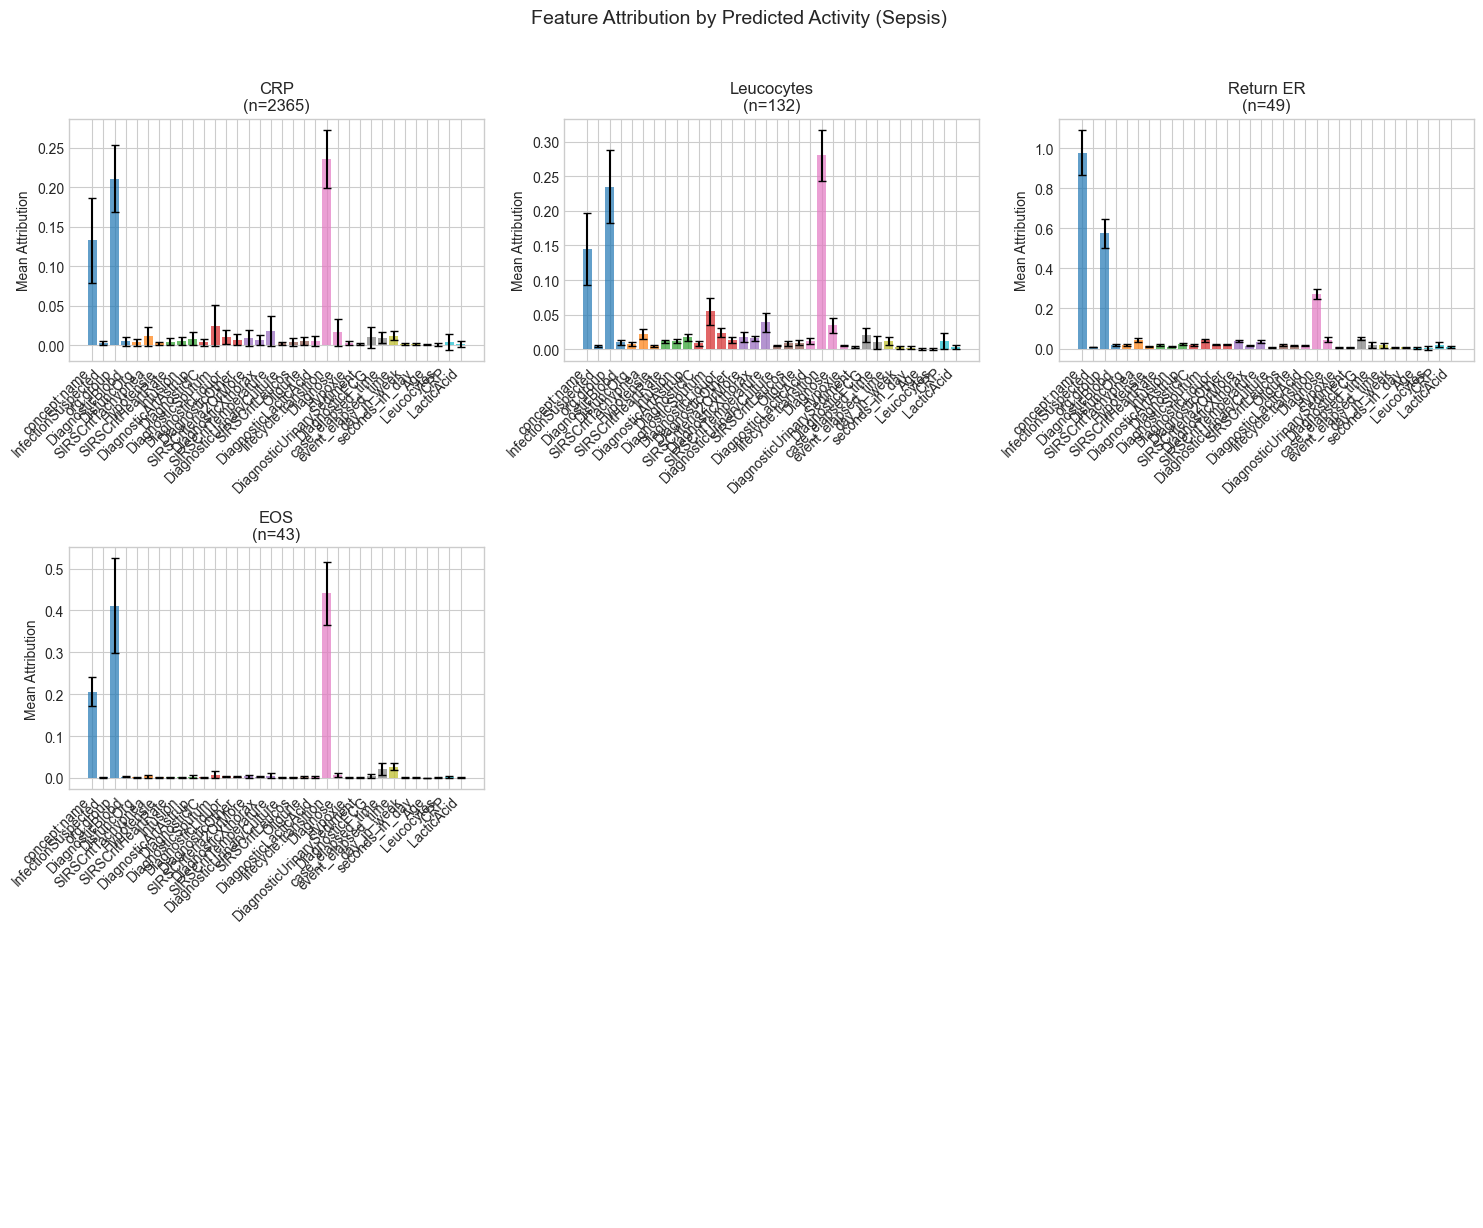

In [11]:
# Views 1-5: Attribution for each of top-5 activities
n_activities = min(5, len(top_activities))
n_cols = min(3, n_activities)
n_rows = (n_activities + n_cols - 1) // n_cols + (1 if n_activities % n_cols != 0 else 0)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
axes = axes.flatten() if n_activities > 1 else [axes]

# Use colormap for dynamic number of features
colors = plt.cm.tab10(np.linspace(0, 1, len(available_features)))

for idx, activity in enumerate(top_activities[:n_activities]):
    ax = axes[idx]
    
    # Filter to this activity
    activity_df = results_df[results_df['predicted_activity'] == activity]
    
    if len(activity_df) > 0:
        means = activity_df[available_features].mean()
        stds = activity_df[available_features].std()
        
        ax.bar(range(len(available_features)), means, yerr=stds, capsize=3,
               color=colors, alpha=0.7)
        ax.set_xticks(range(len(available_features)))
        ax.set_xticklabels(available_features, rotation=45, ha='right')
        ax.set_ylabel('Mean Attribution')
        ax.set_title(f'{activity}\n(n={len(activity_df)})')

# Hide unused subplots
for idx in range(n_activities, len(axes)):
    axes[idx].axis('off')

plt.suptitle(f'Feature Attribution by Predicted Activity ({CONFIG.dataset_name})', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [12]:
# Summary table: Attribution by activity
activity_summary = []

for activity in top_activities:
    activity_df = results_df[results_df['predicted_activity'] == activity]
    
    row = {'Activity': activity, 'Count': len(activity_df)}
    for feat in available_features:
        row[f'{feat}_mean'] = activity_df[feat].mean()
    activity_summary.append(row)

summary_df = pd.DataFrame(activity_summary)
print("\nAttribution Summary by Predicted Activity:")
display(summary_df)


Attribution Summary by Predicted Activity:


,Activity,Count,concept:name_mean,InfectionSuspected_mean,org:group_mean,DiagnosticBlood_mean,DisfuncOrg_mean,SIRSCritTachypnea_mean,Hypotensie_mean,SIRSCritHeartRate_mean,...,DiagnosticUrinarySediment_mean,DiagnosticECG_mean,case_elapsed_time_mean,event_elapsed_time_mean,day_in_week_mean,seconds_in_day_mean,Age_mean,Leucocytes_mean,CRP_mean,LacticAcid_mean
0,CRP,2365,0.133083,0.002441,0.211243,0.004869,0.003421,0.010941,0.002121,0.004476,...,0.001563,0.009638,0.009598,0.011529,0.001459,0.000879,0.000352,0.000381,0.004197,0.001339
1,Leucocytes,132,0.145388,0.004919,0.234964,0.009829,0.007148,0.021775,0.004785,0.011072,...,0.003149,0.020211,0.009848,0.011428,0.002339,0.002284,0.000722,0.000690,0.011366,0.002499
2,Return ER,49,0.979240,0.007627,0.575068,0.019407,0.017353,0.041792,0.011193,0.018440,...,0.007288,0.049255,0.016187,0.015222,0.004974,0.005774,0.002200,0.003731,0.019787,0.005738
3,EOS,43,0.205978,0.001544,0.411087,0.002508,0.001827,0.004269,0.001330,0.002229,...,0.001072,0.004660,0.021164,0.026443,0.000675,0.000800,0.000268,0.000327,0.001642,0.000719


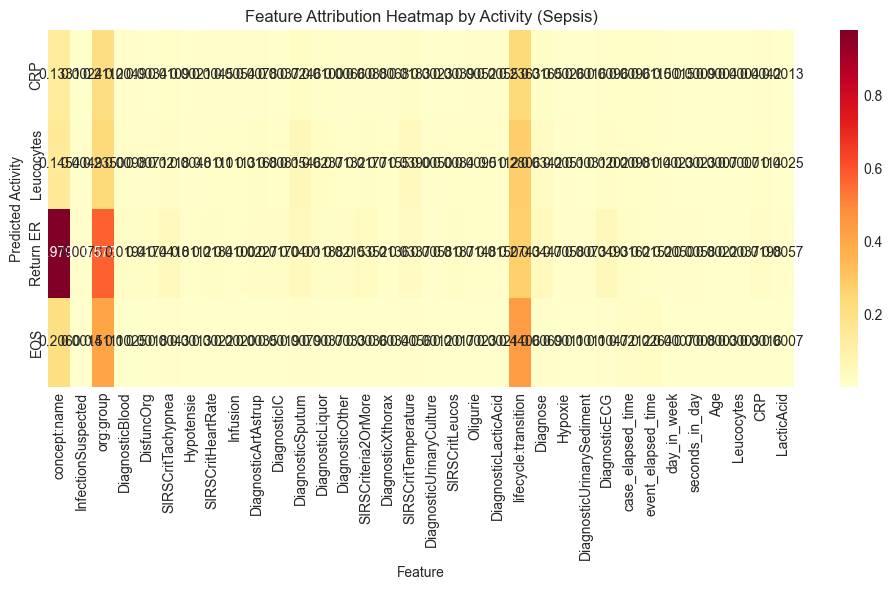

In [13]:
# Views 6-10: Heatmap of feature attribution by activity
# Create pivot table
heatmap_data = summary_df.set_index('Activity')[[f'{f}_mean' for f in available_features]]
heatmap_data.columns = available_features

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(heatmap_data, annot=True, cmap='YlOrRd', fmt='.4f', ax=ax)
ax.set_title(f'Feature Attribution Heatmap by Activity ({CONFIG.dataset_name})')
ax.set_ylabel('Predicted Activity')
ax.set_xlabel('Feature')
plt.tight_layout()
plt.show()

## 7. Save Results

In [14]:
# Save results
output_dir = CONFIG.get_results_dir()

mode_suffix = '_test' if TEST_MODE else '_full'
output_path = output_dir / f'dataset_attribution_results{mode_suffix}.pkl'

with open(output_path, 'wb') as f:
    pickle.dump({
        'results_df': results_df,
        'avg_attribution': avg_attribution.to_dict(),
        'activity_summary': summary_df,
        'config': CONFIG.to_dict(),
        'test_mode': TEST_MODE
    }, f)

print(f"Results saved to: {output_path}")

Results saved to: /Users/philippeichhorn/IdeaProjects/XAI-Probabilistic_Suffix_Prediction_U-ED-LSTM_pub/src/interpretability/notebooks/results/sepsis/dataset_attribution_results_full.pkl


## 8. Summary

In [15]:
print("="*80)
print(f"SUMMARY: Dataset-Level Attribution Analysis")
print("="*80)
print(f"\nDataset: {CONFIG.dataset_name}")
print(f"Mode: {'TEST' if TEST_MODE else 'FULL'}")
print(f"Samples analyzed: {len(results_df)}")
print(f"Total input features: {len(available_features)}")

print(f"\n--- Average Feature Attribution (All {len(available_features)} Features) ---")
# Sort by attribution value
sorted_attrs = avg_attribution[available_features].sort_values(ascending=False)
for feat in sorted_attrs.index:
    print(f"{feat:25s}: {sorted_attrs[feat]:.6f}")

print(f"\n--- Top Predicted Activities ---")
for act in top_activities[:5]:
    print(f"{act}: {activity_counts[act]} predictions")

SUMMARY: Dataset-Level Attribution Analysis

Dataset: Sepsis
Mode: FULL
Samples analyzed: 2589
Total input features: 34

--- Average Feature Attribution (All 34 Features) ---
lifecycle:transition     : 0.242655
org:group                : 0.222657
concept:name             : 0.150935
DiagnosticSputum         : 0.026131
SIRSCritTemperature      : 0.019388
Diagnose                 : 0.017776
SIRSCritTachypnea        : 0.011966
event_elapsed_time       : 0.011842
DiagnosticECG            : 0.010844
DiagnosticLiquor         : 0.010800
case_elapsed_time        : 0.009928
SIRSCriteria2OrMore      : 0.009672
DiagnosticArtAstrup      : 0.008429
DiagnosticXthorax        : 0.007288
DiagnosticOther          : 0.007192
DiagnosticLacticAcid     : 0.005908
Infusion                 : 0.005734
Oligurie                 : 0.005519
DiagnosticBlood          : 0.005358
SIRSCritHeartRate        : 0.005039
CRP                      : 0.004815
SIRSCritLeucos           : 0.004407
DiagnosticIC             : 0.0041